In [1]:
import os
import requests
from PIL import Image, UnidentifiedImageError
from io import BytesIO
from dotenv import load_dotenv
from tqdm import tqdm
from urllib.parse import quote
from sklearn.cluster import DBSCAN
import numpy as np
import torchvision.transforms as T
from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop
import pillow_heif
from scipy.spatial.distance import cosine
import cv2
import json
import pickle
import time

# -------------------------------
# Blurry detection
# -------------------------------
def is_blurry(pil_img, threshold=50):
    img = np.array(pil_img.convert("L"))  # grayscale
    variance = cv2.Laplacian(img, cv2.CV_64F).var()
    return variance < threshold

# -------------------------------
# load token from .env
# -------------------------------
load_dotenv()
ACCESS_TOKEN = os.getenv("GRAPH_ACCESS_TOKEN")
if not ACCESS_TOKEN:
    raise RuntimeError("GRAPH_ACCESS_TOKEN not found!")

HEADERS = {"Authorization": f"Bearer {ACCESS_TOKEN}"}

# -------------------------------
# InsightFace setup
# -------------------------------
app = FaceAnalysis(name='buffalo_l')
app.prepare(ctx_id=0, det_size=(640, 640))

# -------------------------------
# Helper functions
# -------------------------------
def is_image_item(item):
    if "file" not in item:
        return False
    mime = item.get("file", {}).get("mimeType", "")
    name = item.get("name", "").lower()
    has_url = "@microsoft.graph.downloadUrl" in item
    ext_ok = name.endswith((".jpg",".jpeg",".png",".heic",".heif"))
    return has_url and (mime.startswith("image/") or ext_ok)

def list_photos_in_folder(folder_path):
    """
    List all image files in a folder on Microsoft OneDrive via Graph API,
    handling pagination to get more than 200 items.
    """
    encoded_path = quote(folder_path)
    url = f"https://graph.microsoft.com/v1.0/me/drive/root:/{encoded_path}:/children"
    photos = []

    while url:
        resp = requests.get(url, headers=HEADERS)
        if resp.status_code == 401:
            raise RuntimeError("Access token expired, reload environment variable!")
        resp.raise_for_status()
        data = resp.json()

        # Filter only image items
        photos.extend([f for f in data.get("value", []) if is_image_item(f)])

        # Check if there's a next page
        url = data.get("@odata.nextLink")  # None if no more pages

    return photos

def load_photo_image(photo):
    download_url = photo["@microsoft.graph.downloadUrl"]
    try:
        r = requests.get(download_url, timeout=30)
        r.raise_for_status()
    except Exception:
        return None
    data = r.content
    content_type = r.headers.get("Content-Type", "").lower()
    name = photo.get("name", "").lower()
    try:
        img = Image.open(BytesIO(data))
        img = img.convert("RGB")
        return img
    except (UnidentifiedImageError, OSError):
        if ("heic" in name or "heif" in name or "heic" in content_type or "heif" in content_type):
            try:
                heif = pillow_heif.read_heif(data)
                img = heif.to_pillow().convert("RGB")
                return img
            except Exception:
                return None
        return None

# -------------------------------
# Face preprocessing
# -------------------------------
# Set output size to 512x512 instead of 256x256
FACE_SIZE = 512
face_transform = T.Compose([
    T.Resize((FACE_SIZE, FACE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

def detect_and_align_faces(img_pil, size=FACE_SIZE):
    img_np = np.array(img_pil)[:, :, ::-1]
    faces = app.get(img_np)
    results = []
    for face in faces:
        kps = face.kps
        aligned_bgr = norm_crop(img_np, kps, image_size=size, mode='arcface')
        aligned_rgb = aligned_bgr[:, :, ::-1]
        aligned_pil = Image.fromarray(aligned_rgb)

        # Filter: skip blurry or too small faces
        if aligned_pil.width < 50 or aligned_pil.height < 50:
            continue
        if is_blurry(aligned_pil):
            continue

        emb = face.embedding
        emb = emb / (np.linalg.norm(emb) + 1e-12)

        results.append({
            "aligned_pil": aligned_pil,
            "embedding": emb,
        })
    return results

def save_face_image(pil_img, out_path):
    tensor = face_transform(pil_img)
    tensor = tensor * 0.5 + 0.5
    tensor = tensor.clamp(0, 1)
    pil_out = T.ToPILImage()(tensor)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    pil_out.save(out_path, format="JPEG", quality=95)

def merge_close_clusters(centroids, threshold=0.25):
    merged = {}
    used = set()
    for i in range(len(centroids)):
        if i in used:
            continue
        merged[i] = [i]
        for j in range(i + 1, len(centroids)):
            if cosine(centroids[i], centroids[j]) < threshold:
                merged[i].append(j)
                used.add(j)
    return merged

# -------------------------------
# Main loop with checkpointing
# -------------------------------
folders = ["Bilder/Eigene Aufnahmen/2023",
           "Bilder/Eigene Aufnahmen/2024",
           "Bilder/Eigene Aufnahmen/2025"]

ML_DIR = "../../diffusion_photos"
os.makedirs(ML_DIR, exist_ok=True)

checkpoint_file = os.path.join(ML_DIR, "faces_checkpoint.pkl")
processed_photos_file = os.path.join(ML_DIR, "processed_photos.json")

# Load previous checkpoint if exists
if os.path.exists(checkpoint_file):
    with open(checkpoint_file, "rb") as f:
        checkpoint = pickle.load(f)
        all_faces = checkpoint.get("all_faces", [])
        meta = checkpoint.get("meta", [])
else:
    all_faces = []
    meta = []

# Load processed photo list
if os.path.exists(processed_photos_file):
    with open(processed_photos_file, "r") as f:
        processed_photos = set(json.load(f))
else:
    processed_photos = set()

# -------------------------------
# Process folders
# -------------------------------
for folder in folders:
    photos = list_photos_in_folder(folder)
    for photo in tqdm(photos):
        photo_id = f"{folder}/{photo['name']}"
        if photo_id in processed_photos:
            continue  # Skip already processed

        img_pil = load_photo_image(photo)
        if img_pil is None:
            processed_photos.add(photo_id)
            continue

        faces = detect_and_align_faces(img_pil)
        for idx_face, f in enumerate(faces):
            all_faces.append(f["embedding"])
            meta.append({
                "aligned_pil": f["aligned_pil"],
                "photo_name": photo["name"],
                "face_index": idx_face,
            })

        # Mark photo as processed
        processed_photos.add(photo_id)

        # Save checkpoint every 100 photos
        if len(processed_photos) % 100 == 0:
            with open(checkpoint_file, "wb") as f:
                pickle.dump({"all_faces": all_faces, "meta": meta}, f)
            with open(processed_photos_file, "w") as f:
                json.dump(list(processed_photos), f)

# Save final checkpoint
with open(checkpoint_file, "wb") as f:
    pickle.dump({"all_faces": all_faces, "meta": meta}, f)
with open(processed_photos_file, "w") as f:
    json.dump(list(processed_photos), f)

# -------------------------------
# Continue with clustering and saving
# -------------------------------
if len(all_faces) == 0:
    print("No faces found.")
else:
    X = np.stack(all_faces, axis=0)

    # ---- DBSCAN (Cosine) ----
    clustering = DBSCAN(eps=0.35, min_samples=3, metric="cosine").fit(X)
    labels = clustering.labels_

    # ---- Cluster centroids ----
    cluster_ids = sorted(set(labels) - {-1})
    centroids = []
    for cid in cluster_ids:
        vecs = X[labels == cid]
        c = vecs.mean(axis=0)
        c = c / (np.linalg.norm(c) + 1e-12)
        centroids.append(c)

    # ---- Merge clusters ----
    merged = merge_close_clusters(centroids, threshold=0.25)

    # ---- Mapping old → new ----
    cluster_to_person = {}
    for new_id, old_ids in enumerate(merged.values()):
        for old_id in old_ids:
            cluster_to_person[cluster_ids[old_id]] = new_id

    new_labels = []
    for lbl in labels:
        if lbl == -1:
            new_labels.append(-1)
        else:
            new_labels.append(cluster_to_person[lbl])
    new_labels = np.array(new_labels)

    # ---- Save faces ----
    counters = {}
    for i, label in enumerate(new_labels):
        if label == -1:
            person_dir = os.path.join(ML_DIR, "unknown")
        else:
            person_dir = os.path.join(ML_DIR, f"person_{label:02d}")

        counters.setdefault(person_dir, 0)
        counters[person_dir] += 1
        idx = counters[person_dir]

        base = meta[i]["photo_name"]
        out_name = f"{os.path.splitext(base)[0]}_face{meta[i]['face_index']:02d}_{idx:04d}.jpg"
        out_path = os.path.join(person_dir, out_name)

        save_face_image(meta[i]["aligned_pil"], out_path)


/opt/homebrew/Caskroom/miniconda/base/envs/face_craft_env/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/thomasbeisteiner/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/thomasbeisteiner/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/thomasbeisteiner/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/thomasbeisteiner/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/thomasbeisteiner/.insightface/models/buffalo_l/w600k_r5

 10%|█         | 3/29 [00:04<00:38,  1.47s/it]/opt/homebrew/Caskroom/miniconda/base/envs/face_craft_env/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
100%|██████████| 894/894 [16:26<00:00,  1.10s/it]
/opt/homebrew/Caskroom/miniconda/base/envs/face_craft_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/face_craft_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/Caskroom/miniconda/base/envs/face_craft_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [3]:
import os
import shutil

# CONFIG: Set your own person folder
MY_PERSON_FOLDER = "person_00" 

ML_DIR = "../../diffusion_photos"

def reorganize_ml_photos(ml_dir, my_folder):
    me_path = os.path.join(ml_dir, my_folder)
    me_target = os.path.join(ml_dir, "me")
    if os.path.exists(me_path):
        if os.path.exists(me_target):
            shutil.rmtree(me_target)
        os.rename(me_path, me_target)
        print(f"Renamed {my_folder} to 'me'")
    others_target = os.path.join(ml_dir, "others")
    if not os.path.exists(others_target):
        os.makedirs(others_target)
    for folder in os.listdir(ml_dir):
        folder_path = os.path.join(ml_dir, folder)
        if folder in ["me", "others"] or not os.path.isdir(folder_path):
            continue
        # if folder == "unknown":
        #     shutil.rmtree(folder_path)
        #     print(f"Deleted folder 'unknown'")
        #     continue
        for file in os.listdir(folder_path):
            src = os.path.join(folder_path, file)
            dst = os.path.join(others_target, file)
            shutil.move(src, dst)
        shutil.rmtree(folder_path)
        print(f"Moved all images from {folder} to 'others' and removed {folder}")

reorganize_ml_photos(ML_DIR, MY_PERSON_FOLDER)

Renamed person_00 to 'me'
Moved all images from person_07 to 'others' and removed person_07
Moved all images from person_09 to 'others' and removed person_09
Moved all images from person_08 to 'others' and removed person_08
Moved all images from person_01 to 'others' and removed person_01
Moved all images from person_06 to 'others' and removed person_06
Moved all images from person_12 to 'others' and removed person_12
Moved all images from person_13 to 'others' and removed person_13
Moved all images from person_14 to 'others' and removed person_14
Moved all images from person_03 to 'others' and removed person_03
Moved all images from person_04 to 'others' and removed person_04
Moved all images from person_05 to 'others' and removed person_05
Moved all images from person_02 to 'others' and removed person_02
Moved all images from unknown to 'others' and removed unknown
Moved all images from person_11 to 'others' and removed person_11
Moved all images from person_10 to 'others' and remove

In [2]:
import os
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torchvision import transforms
from PIL import Image

from diffusers import StableDiffusionPipeline, DDPMScheduler
from peft import LoraConfig, get_peft_model

# ---------------- CONFIG ----------------
MODEL_ID = "runwayml/stable-diffusion-v1-5"
DATA_DIR = "../../diffusion_photos/me"
OUTPUT_DIR = "../../models/lora_me"
PROMPT = "a photo of <me> person"

TRAIN_STEPS = 1500
LR = 1e-4
IMAGE_SIZE = 512

DEVICE = "mps"
DTYPE = torch.float32
# ---------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------- LOAD PIPELINE --------
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE
)
pipe.to(DEVICE)

pipe.scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

pipe.vae.requires_grad_(False)
pipe.text_encoder.requires_grad_(False)

# -------- LoRA --------
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.05,
    bias="none",
    task_type="UNET"
)

pipe.unet = get_peft_model(pipe.unet, lora_config)
pipe.unet.train()

optimizer = AdamW(pipe.unet.parameters(), lr=LR)

# -------- DATASET --------
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

image_paths = [
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if f.lower().endswith(".jpg")
]

assert len(image_paths) > 0, "Keine Bilder gefunden"

# -------- TEXT EMBEDDING --------
with torch.no_grad():
    text_ids = pipe.tokenizer(
        PROMPT,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    ).input_ids.to(DEVICE)

    text_embeddings = pipe.text_encoder(text_ids)[0]

# -------- TRAIN LOOP --------
for step in range(TRAIN_STEPS):
    img_path = image_paths[step % len(image_paths)]
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(DEVICE)

    noise = torch.randn((1, 4, 64, 64), device=DEVICE)
    timestep = torch.randint(
        0,
        pipe.scheduler.config.num_train_timesteps,
        (1,),
        device=DEVICE
    ).long()

    with torch.no_grad():
        latents = pipe.vae.encode(image).latent_dist.sample()
        latents = latents * 0.18215

    noisy_latents = pipe.scheduler.add_noise(latents, noise, timestep)

    noise_pred = pipe.unet(
        noisy_latents,
        timestep,
        encoder_hidden_states=text_embeddings
    ).sample

    loss = F.mse_loss(noise_pred, noise)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if step % 50 == 0:
        print(f"Step {step}/{TRAIN_STEPS} | Loss: {loss.item():.4f}")

# -------- SAVE --------
pipe.unet.save_pretrained(OUTPUT_DIR)
print("LoRA training finished")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


Step 0/1500 | Loss: 0.0311
Step 50/1500 | Loss: 0.0894
Step 100/1500 | Loss: 0.1150
Step 150/1500 | Loss: 0.1657
Step 200/1500 | Loss: 0.4435
Step 250/1500 | Loss: 0.1770
Step 300/1500 | Loss: 0.0133
Step 350/1500 | Loss: 0.3259
Step 400/1500 | Loss: 0.0324
Step 450/1500 | Loss: 0.0085
Step 500/1500 | Loss: 0.0695
Step 550/1500 | Loss: 0.1226
Step 600/1500 | Loss: 0.0547
Step 650/1500 | Loss: 0.0058
Step 700/1500 | Loss: 0.0054
Step 750/1500 | Loss: 0.0407
Step 800/1500 | Loss: 0.6201
Step 850/1500 | Loss: 0.0924
Step 900/1500 | Loss: 0.1727
Step 950/1500 | Loss: 0.0113
Step 1000/1500 | Loss: 0.1140
Step 1050/1500 | Loss: 0.2768
Step 1100/1500 | Loss: 0.2434
Step 1150/1500 | Loss: 0.0466
Step 1200/1500 | Loss: 0.0200
Step 1250/1500 | Loss: 0.0087
Step 1300/1500 | Loss: 0.0446
Step 1350/1500 | Loss: 0.0519
Step 1400/1500 | Loss: 0.0041
Step 1450/1500 | Loss: 0.4716
LoRA training finished


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


  0%|          | 0/30 [00:00<?, ?it/s]

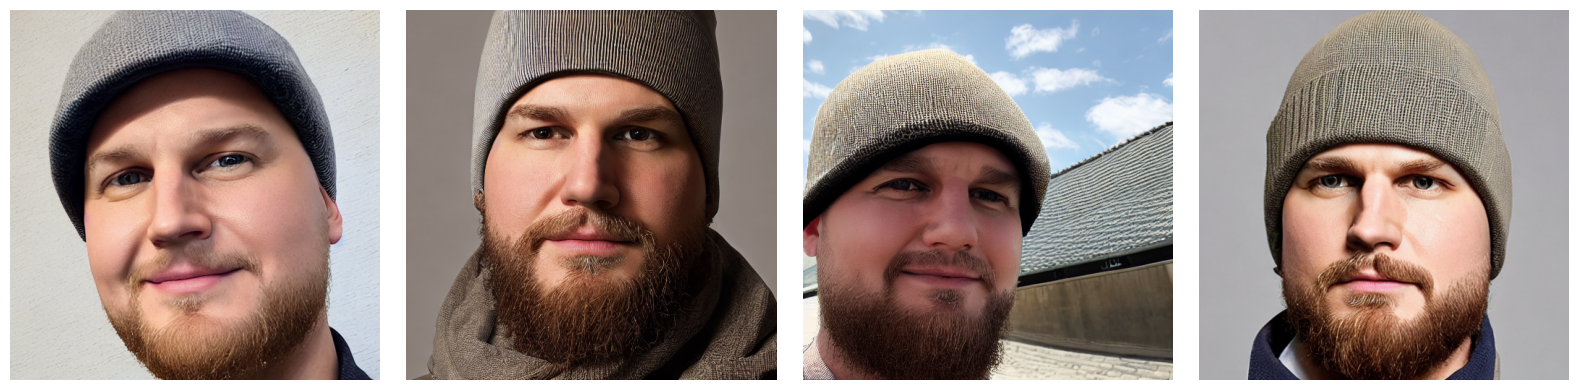

In [13]:
import torch
from diffusers import StableDiffusionPipeline
from peft import PeftModel
import matplotlib.pyplot as plt

DEVICE = "mps"
DTYPE = torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=DTYPE
)

pipe.to(DEVICE)

pipe.unet = PeftModel.from_pretrained(
    pipe.unet,
    "../../models/lora_me"
)

pipe.unet.eval()

prompt = "a portrait of <me> person, fully clothed, head and shoulders, neutral background, same facial structure, same eyes, same nose, same jawline, hat"
negative_prompt = "blurry, deformed, bad anatomy, female, child, old, different face, different person"

#prompt = "a portrait of <me> person, fully clothed, head and shoulders, neutral background"
#negative_prompt = "blurry, deformed, bad anatomy, different face, different person"

# Generate 4 images and show them with matplotlib
images = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    num_images_per_prompt=4
).images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()